In [1]:
import pandas as pd
import time
from sklearn.model_selection import cross_val_score


X_test = pd.read_csv('./data_ml/X_test.csv')
X_train = pd.read_csv('./data_ml/X_train.csv')
y_test = pd.read_csv('./data_ml/y_test.csv')
y_train = pd.read_csv('./data_ml/y_train.csv')

X_train

,Profit after tax last year,Sales last year,positive_opm_last_year,profitable_last_year,material_cost_ratio,employee_cost_ratio,total_cost_ratio,depreciation_ratio,log_sales,log_market_cap,asset_turnover
0,2395.70,20520.98,1,1,0.037279,5.187033,5.224312,9.245757,9.929252,11.532095,0.201315
1,0.19,5.97,1,1,150.000000,27.135678,177.135678,10.385260,1.941615,2.224624,0.723636
2,26.72,127.55,1,1,2.971384,24.539396,27.510780,6.507252,4.856318,8.058618,0.040365
3,0.10,7.38,0,1,150.000000,0.542005,150.542005,0.000000,2.125848,2.204972,0.914498
4,3880.43,23565.47,1,1,0.000000,13.493047,13.493047,0.000000,10.067580,10.680905,0.541537
...,...,...,...,...,...,...,...,...,...,...,...
3328,-373.95,422.85,0,0,1.951046,50.178550,52.129597,14.837413,6.049380,8.054729,0.134338
3329,11.21,245.57,1,1,35.887934,1.136132,37.024066,0.215824,5.507646,6.151562,0.524218
3330,9.45,117.75,1,1,64.416136,2.276008,66.692144,0.866242,4.777020,5.728052,0.384339
3331,259.37,1801.56,1,1,1.901130,5.155532,7.056662,2.431781,7.496963,7.658615,0.850667


# Sprawdź czy
- liczba wierszy sie zgadza X_train / y_train
- kolejność obserwacji (brak shuffle)
- czy y_train zawiera 4 klasy (negative, low, medium, high)

In [2]:
print(X_train.shape == y_train.shape, X_train.shape, y_train.shape)
print(X_test.shape == y_test.shape, X_test.shape, y_test.shape)


False (3333, 11) (3333, 1)
False (834, 11) (834, 1)


In [3]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

y_train_encoded

c:\Users\Jan Szczepanski\Desktop\analiza\venv\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\Jan Szczepanski\Desktop\analiza\venv\Lib\site-packages\sklearn\preprocessing\_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


array([3, 2, 3, ..., 1, 2, 3], shape=(3333,))

In [4]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
gradient_boosting = GradientBoostingClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
gradient_boosting.fit(X_train, y_train_encoded)

y_train_pred_gb = gradient_boosting.predict(X_train)
train_acc_gb = accuracy_score(y_train_encoded, y_train_pred_gb)


y_pred_gb = gradient_boosting.predict(X_test)

test_accuracy = accuracy_score(y_test_encoded, y_pred_gb)

overfit_gb = train_acc_gb - test_accuracy

print(f'Train Accuracy: {train_acc_gb*100:.4f}%')
print(f'Test Accuracy: {test_accuracy*100:.4f}%')
print(f'Overfitting: {overfit_gb:.4f}')


print("Classification Report:")
print(classification_report(y_test_encoded, y_pred_gb))

print("Confusion Matrix:")
print(confusion_matrix(y_test_encoded, y_pred_gb))

Train Accuracy: 97.8098%
Test Accuracy: 78.8969%
Overfitting: 0.1891
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       118
           1       0.80      0.81      0.81       282
           2       0.66      0.64      0.65       227
           3       0.79      0.81      0.80       207

    accuracy                           0.79       834
   macro avg       0.81      0.81      0.81       834
weighted avg       0.79      0.79      0.79       834

Confusion Matrix:
[[116   1   1   0]
 [  0 228  43  11]
 [  0  47 146  34]
 [  0   8  31 168]]


In [5]:
import xgboost as xgb

xgb_classifier = xgb.XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)

print("\nRunning 5-fold cross-validation...")
cv_scores_xgb = cross_val_score(xgb_classifier, X_train, y_train_encoded, cv=5, scoring='accuracy', n_jobs=-1)
print(f"CV Accuracy: {cv_scores_xgb.mean():.4f} (+/- {cv_scores_xgb.std():.4f})")

xgb_classifier.fit(X_train, y_train_encoded)

y_train_pred_xgb = xgb_classifier.predict(X_train)
train_acc_xgb = accuracy_score(y_train_encoded, y_train_pred_xgb)

y_pred_xgb = xgb_classifier.predict(X_test)

test_accuracy_xgb = accuracy_score(y_test_encoded, y_pred_xgb)
overfit_xgb = train_acc_xgb - test_accuracy_xgb

print(f'Train Accuracy: {train_acc_xgb*100:.4f}%')
print(f'XGBoost Test Accuracy: {test_accuracy_xgb*100:.4f}%')
print(f'Overfitting: {overfit_xgb:.4f}')

print("Classification Report:")
print(classification_report(y_test_encoded, y_pred_xgb))

print("Confusion Matrix:")
print(confusion_matrix(y_test_encoded, y_pred_xgb))


Running 5-fold cross-validation...
CV Accuracy: 0.7906 (+/- 0.0155)
Train Accuracy: 92.9793%
XGBoost Test Accuracy: 78.4173%
Overfitting: 0.1456
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       118
           1       0.79      0.82      0.80       282
           2       0.66      0.61      0.63       227
           3       0.79      0.81      0.80       207

    accuracy                           0.78       834
   macro avg       0.81      0.81      0.81       834
weighted avg       0.78      0.78      0.78       834

Confusion Matrix:
[[116   1   1   0]
 [  0 231  40  11]
 [  0  53 139  35]
 [  0   8  31 168]]


In [6]:
from sklearn.model_selection import RandomizedSearchCV
param_gird = {
    'n_estimators': [50, 100, 150,300 , 500],
    'max_depth': [3, 5, 8],
    'learning_rate': [0.01, 0.1, 0.2],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha': [0, 0.01, 0.1, 1, 10],
    'reg_lambda': [1, 1.5, 2.0, 0.5, 0.7]
}

random_search = RandomizedSearchCV(estimator=xgb_classifier, param_distributions=param_gird, n_iter=100, scoring='accuracy', cv=10, verbose=2, random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train_encoded)

best_xgb = random_search.best_estimator_

print("Best Hyperparameters:", random_search.best_params_)
print("Best Cross-Validation Score:", random_search.best_score_)

Fitting 10 folds for each of 100 candidates, totalling 1000 fits
Best Hyperparameters: {'subsample': 1.0, 'reg_lambda': 0.7, 'reg_alpha': 1, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.2, 'colsample_bytree': 0.8}
Best Cross-Validation Score: 0.8007732283181385


In [7]:
print("\nRunning 5-fold CV with best model...")
cv_scores_xgb_tuned = cross_val_score(best_xgb, X_train, y_train_encoded, cv=5, scoring='accuracy', n_jobs=-1)
print(f"5-fold CV Accuracy: {cv_scores_xgb_tuned.mean():.4f} (+/- {cv_scores_xgb_tuned.std():.4f})")

# Train final model
best_xgb.fit(X_train, y_train_encoded)

# ADD: Train accuracy for overfitting
y_train_pred_xgb_tuned = best_xgb.predict(X_train)
train_acc_xgb_tuned = accuracy_score(y_train_encoded, y_train_pred_xgb_tuned)



Running 5-fold CV with best model...
5-fold CV Accuracy: 0.7939 (+/- 0.0060)


In [8]:
pred_xgb_hyper = best_xgb.predict(X_test)
test_accuracy_xgb_hyper = accuracy_score(y_test_encoded, pred_xgb_hyper)

overfit_xgb_tuned = train_acc_xgb_tuned - test_accuracy_xgb_hyper

print(f'Train Accuracy: {train_acc_xgb_tuned*100:.4f}%')
print(f'XGBoost Test Accuracy: {test_accuracy_xgb_hyper*100:.4f}%')
print(f'Overfitting: {overfit_xgb_tuned:.4f}')

print("\nClassification Report:")
print(classification_report(y_test_encoded, pred_xgb_hyper))

print("Confusion Matrix:")
print(confusion_matrix(y_test_encoded, pred_xgb_hyper))

Train Accuracy: 95.0495%
XGBoost Test Accuracy: 79.0168%
Overfitting: 0.1603

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       118
           1       0.79      0.84      0.81       282
           2       0.67      0.62      0.65       227
           3       0.80      0.80      0.80       207

    accuracy                           0.79       834
   macro avg       0.81      0.81      0.81       834
weighted avg       0.79      0.79      0.79       834

Confusion Matrix:
[[116   1   1   0]
 [  1 236  35  10]
 [  0  54 141  32]
 [  0   9  32 166]]


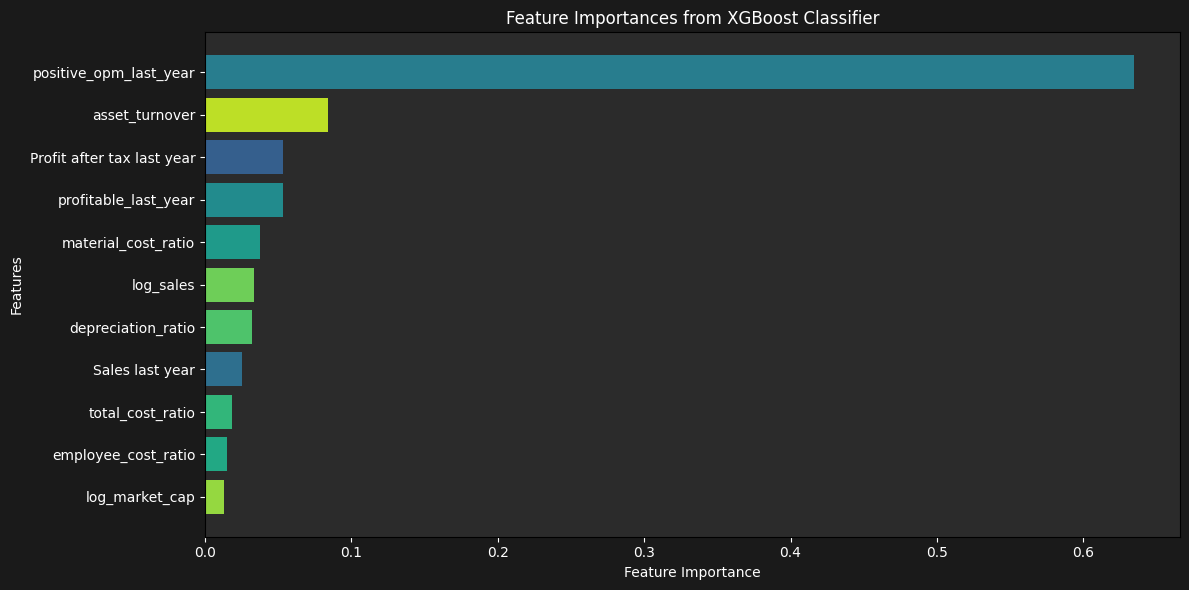

In [9]:
feature_importances = best_xgb.feature_importances_ 
features = X_train.columns

# sort and plot
import matplotlib.pyplot as plt
import numpy as np

indices = np.argsort(feature_importances)[::-1]
y_pos = np.arange(len(features))

fig, ax = plt.subplots(figsize=(12, 6))

colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(features)))

# Colors aligned with sorted features
colors_sorted = colors[indices]

# Horizontal bar chart
ax.barh(y_pos, feature_importances[indices], align='center', color=colors_sorted)

# Invert y-axis so the most important is on top
ax.set_yticks(y_pos)
ax.set_yticklabels(np.array(features)[indices])
ax.invert_yaxis()

ax.set_xlabel('Feature Importance', color='white')
ax.set_ylabel('Features', color='white')
ax.set_title('Feature Importances from XGBoost Classifier', color='white')

# Set darker background
ax.set_facecolor('#2b2b2b')
fig.patch.set_facecolor('#1a1a1a')
ax.tick_params(colors='white')

plt.tight_layout()
plt.show()